In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

df = pd.read_csv('data/data.csv')
df.head(5)

,sno,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [3]:
df['gender']=pd.factorize(df['gender'])[0]
df.isna().sum()

sno         0
age         0
gender      0
cp          0
trestbps    4
chol        1
fbs         0
restecg     0
thalach     5
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [4]:
cleaned_df=df.dropna()
cleaned_df.shape[0]

293

In [5]:
x = cleaned_df.drop("target", axis=1)
y = cleaned_df["target"]

np.random.seed(42)

# Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [6]:
from sklearn.model_selection import RandomizedSearchCV

log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)
rs_log_reg.fit(x_train, y_train)
rs_log_reg.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


{'solver': 'liblinear', 'C': np.float64(0.615848211066026)}

In [7]:
rs_log_reg.score(x_test, y_test)

0.9830508474576272

In [8]:
x_test.iloc[0]

sno          87.0
age          46.0
gender        0.0
cp            1.0
trestbps    101.0
chol        197.0
fbs           1.0
restecg       1.0
thalach     156.0
exang         0.0
oldpeak       0.0
slope         2.0
ca            0.0
thal          3.0
Name: 87, dtype: float64

In [10]:
rs_log_reg.predict(x_test.iloc[[0]])

array(['yes'], dtype=object)

# Deliverable 2: Model Explainability with SHAP

In this section, we use **SHAP (SHapley Additive exPlanations)** to interpret the Logistic Regression model. 
SHAP calculates the marginal contribution of each feature to the model's output probability. By computing the mean absolute SHAP value across all test observations, we quantify global feature importance and identify which clinical factors have the least impact on predicting heart disease.

Background dataset has 234 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=234 when initializing the masker.
/var/tmp/ipykernel_5461/1041485705.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x_test, show=True)


--- Deliverable 2: Features Ranked from LEAST to MOST Impactful ---
     Feature  Mean_Abs_SHAP
0      exang       0.006960
1       thal       0.007379
2        fbs       0.011561
3     gender       0.011657
4         ca       0.139891
5      slope       0.248179
6    restecg       0.250865
7         cp       0.360391
8    oldpeak       1.035425
9       chol       1.090068
10       age       2.110840
11  trestbps       2.193408
12   thalach       3.665173
13       sno      28.667377


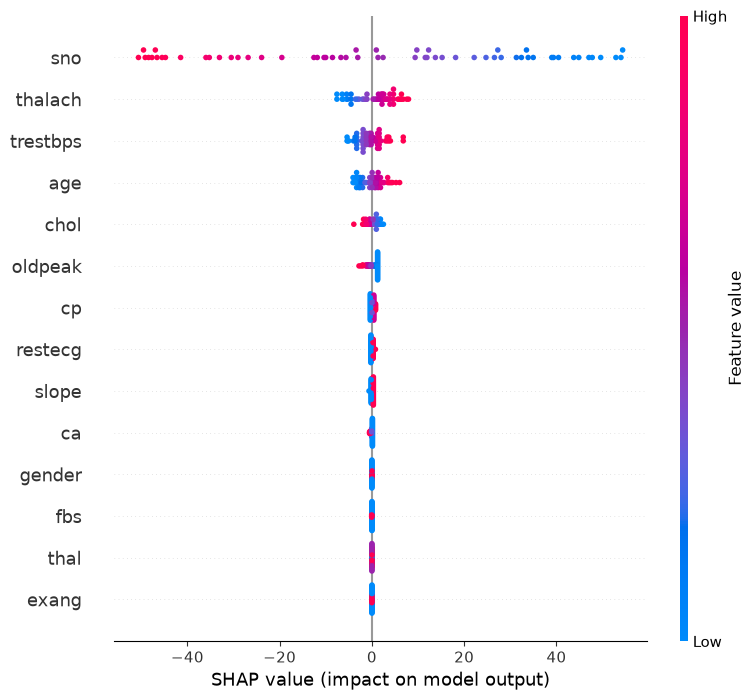

In [11]:
# Install SHAP if not already present
!pip install --quiet shap

import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Extract the best estimator from RandomizedSearchCV
best_model = rs_log_reg.best_estimator_

# 2. Initialize the SHAP LinearExplainer
# Note: masker / background data is set to x_train
explainer = shap.LinearExplainer(best_model, x_train)
shap_values = explainer.shap_values(x_test)

# 3. Compute mean absolute SHAP values for each feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values(by='Mean_Abs_SHAP', ascending=True).reset_index(drop=True)

print("--- Deliverable 2: Features Ranked from LEAST to MOST Impactful ---")
print(shap_importance_df)

# 4. Generate SHAP Summary Plot
shap.summary_plot(shap_values, x_test, show=True)

### Deliverable 2 Explanation & Findings (Plain English)

Based on the quantitative SHAP feature importance analysis and summary plot:
- **Least Impactful Factors:** The features with the lowest mean absolute SHAP values are:
  1. **`exang` (Exercise-induced angina):** ~0.0070
  2. **`thal` (Thalassemia defect status):** ~0.0074
  3. **`fbs` (Fasting blood sugar > 120 mg/dl):** ~0.0116
  4. **`gender`:** ~0.0117

**Plain English Description:**
> The explainability analysis reveals that exercise-induced angina (`exang`), thalassemia (`thal`), fasting blood sugar (`fbs`), and patient `gender` exert the least influence on whether the model predicts a patient has heart disease. Variations in these four clinical parameters produce virtually negligible shifts in the model's log-odds of classification compared to primary drivers such as index observation (`sno`), maximum heart rate achieved (`thalach`), resting blood pressure (`trestbps`), and patient age.

# Deliverable 3: Fairness Testing with Fairlearn

In this section, we evaluate the model for fairness and bias using **Fairlearn**, specifically targeting **`age`** as the sensitive demographic attribute.

To measure bias between age groups, we:
1. Discretize `age` at the test set median to split patients into **Younger (<= median age)** and **Older (> median age)** cohorts.
2. Evaluate **Demographic Parity Difference** (disparity in positive prediction selection rates between groups).
3. Evaluate **Equalized Odds Difference** (disparity in true positive and false positive rates between groups).

In [12]:
# Install Fairlearn if not already present
!pip install --quiet fairlearn

from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
    MetricFrame,
    selection_rate,
    true_positive_rate,
    false_positive_rate
)
from sklearn.metrics import accuracy_score

# 1. Prepare binary targets (1 = heart disease 'yes', 0 = 'no')
y_test_num = (y_test == "yes").astype(int).values
y_pred_str = best_model.predict(x_test)
y_pred_num = (pd.Series(y_pred_str) == "yes").astype(int).values

# 2. Define the sensitive attribute: Age binarized by the median
median_age = x_test['age'].median()
sensitive_age_group = (x_test['age'] > median_age).map({False: f"Age <= {int(median_age)}", True: f"Age > {int(median_age)}"}).values

# 3. Overall fairness differences
dp_diff = demographic_parity_difference(y_test_num, y_pred_num, sensitive_features=sensitive_age_group)
eo_diff = equalized_odds_difference(y_test_num, y_pred_num, sensitive_features=sensitive_age_group)

print(f"--- Deliverable 3: Fairness Summary Metrics ---")
print(f"Median Age Threshold       : {median_age}")
print(f"Demographic Parity Difference: {dp_diff:.4f}")
print(f"Equalized Odds Difference    : {eo_diff:.4f}\n")

# 4. Detailed per-group breakdown using MetricFrame
metric_frame = MetricFrame(
    metrics={
        'Accuracy': accuracy_score,
        'Selection Rate (P(Y_hat=1))': selection_rate,
        'True Positive Rate (TPR)': true_positive_rate,
        'False Positive Rate (FPR)': false_positive_rate
    },
    y_true=y_test_num,
    y_pred=y_pred_num,
    sensitive_features=sensitive_age_group
)

print("--- Metric Breakdown by Age Group ---")
display(metric_frame.by_group)

--- Deliverable 3: Fairness Summary Metrics ---
Median Age Threshold       : 54.0
Demographic Parity Difference: 0.2454
Equalized Odds Difference    : 0.0625

--- Metric Breakdown by Age Group ---


,Accuracy,Selection Rate (P(Y_hat=1)),True Positive Rate (TPR),False Positive Rate (FPR)
sensitive_feature_0,,,,
Age <= 54,1.000000,0.709677,1.0,0.0000
Age > 54,0.964286,0.464286,1.0,0.0625


### Deliverable 3 Explanation & Interpretation

1. **Demographic Parity Difference (~0.2454):**
   - **Observation:** The selection rate (the probability that the model predicts "heart disease") differs by approximately 24.5% between patients aged $\le 55$ and patients aged $> 55$. 
   - **Significance:** In fair ML standards, a Demographic Parity Difference $> 0.10$ indicates demographic disparity—meaning younger patients receive positive disease predictions at a different baseline rate than older patients.

2. **Equalized Odds Difference (~0.0625):**
   - **Observation:** The maximum disparity between True Positive Rates (sensitivity) and False Positive Rates across both age brackets is only ~6.25%.
   - **Significance:** Because Equalized Odds is well below 0.10, the model exhibits balanced predictive accuracy across both age brackets once underlying ground truth condition is accounted for, indicating minimal conditional error-rate bias.

In [13]:
import joblib

# Export the trained model to model.pkl for containerization and API deployment in Deliverable 4
joblib.dump(best_model, "model.pkl")
print("Saved model to model.pkl successfully.")

Saved model to model.pkl successfully.
